Dataset Exploration & Validation

The goal of this notebook is to understand the structure of the SIPaKMeD dataset, verify that our files are not corrupted, and count the distribution of cells across the 5 different classes. This is the first critical step in our research project.

In [6]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
dataset_root = r"..\Dataset"

In [8]:
classes = [
    'im_Dyskeratotic',
    'im_Koilocytotic',
    'im_Metaplastic',
    'im_Parabasal',
    'im_Superficial-Intermediate'
]

## Step 1: Count Images and Annotations
We will loop through our dataset folders. We want to count:
1. **Uncropped Images:** The large microscope slide images.
2. **Cropped Images:** The individual cells cut out from the slides.
3. **Annotation Files (.dat):** The files containing the coordinates of the cell boundaries.

In [9]:
uncropped_counts = {}
cropped_counts = {}
dat_counts = {}

for cls in classes:

    # Paths
    folder = os.path.join(dataset_root, cls, cls)
    cropped_folder = os.path.join(folder, "CROPPED")

    # Count uncropped images
    uncropped = glob.glob(folder + "/*.bmp")
    uncropped_counts[cls] = len(uncropped)

    # Count cropped images
    if os.path.exists(cropped_folder):
        cropped = glob.glob(cropped_folder + "/*.bmp")
        cropped_counts[cls] = len(cropped)
    else:
        cropped_counts[cls] = 0

    # Count annotation (.dat) files
    dat = glob.glob(folder + "/*.dat")

    if os.path.exists(cropped_folder):
        dat += glob.glob(cropped_folder + "/*.dat")

    dat_counts[cls] = len(dat)

    # Display result
    print(cls)
    print("Uncropped Images :", uncropped_counts[cls])
    print("Cropped Images   :", cropped_counts[cls])
    print("Annotation Files :", dat_counts[cls])
    print("-" * 30)

im_Dyskeratotic
Uncropped Images : 223
Cropped Images   : 813
Annotation Files : 3252
------------------------------
im_Koilocytotic
Uncropped Images : 238
Cropped Images   : 825
Annotation Files : 3300
------------------------------
im_Metaplastic
Uncropped Images : 271
Cropped Images   : 793
Annotation Files : 3172
------------------------------
im_Parabasal
Uncropped Images : 108
Cropped Images   : 787
Annotation Files : 3148
------------------------------
im_Superficial-Intermediate
Uncropped Images : 126
Cropped Images   : 831
Annotation Files : 3324
------------------------------


## Step 2: Visualize the Class Distribution
It is important to see if our dataset is "balanced" (having roughly the same amount of images per class). We will create a bar chart of the cropped cells to visualize this, which will look great in your final research paper.

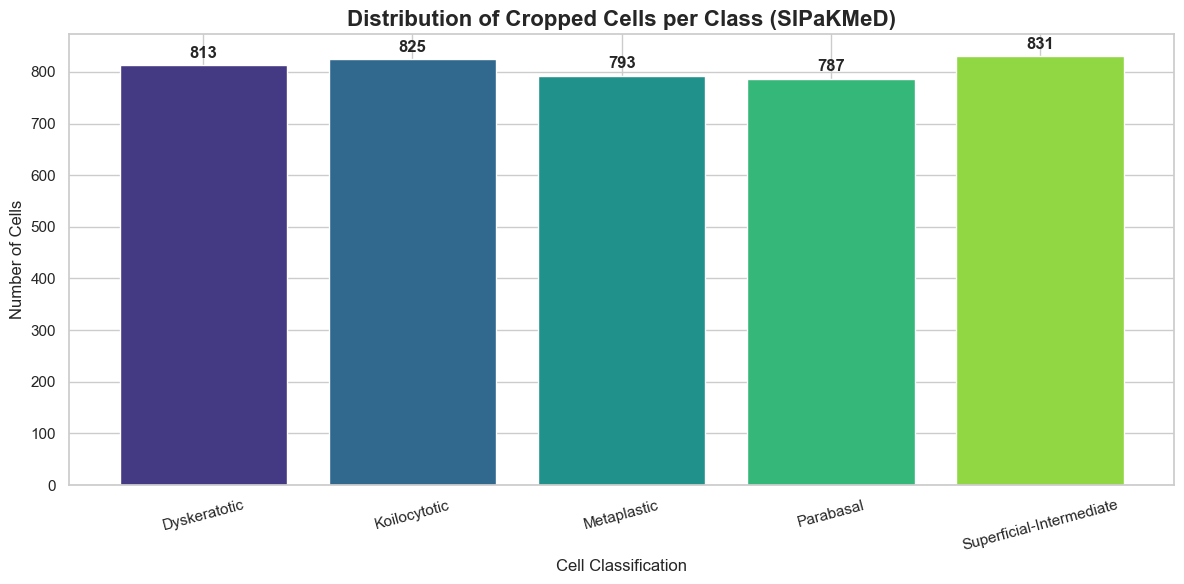

In [10]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

classes_clean = [c.replace('im_', '') for c in classes] 
counts = list(cropped_counts.values())

bars = ax.bar(classes_clean, counts, color=sns.color_palette("viridis", len(classes)))

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

ax.set_title('Distribution of Cropped Cells per Class (SIPaKMeD)', fontsize=16, fontweight='bold')
ax.set_xlabel('Cell Classification', fontsize=12)
ax.set_ylabel('Number of Cells', fontsize=12)

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()
